Dataset shape: (550502, 19)

Running TimeSeries Cross Validation...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006569 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1303
[LightGBM] [Info] Number of data points in the train set: 91752, number of used features: 18
[LightGBM] [Info] Start training from score 29.170988
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

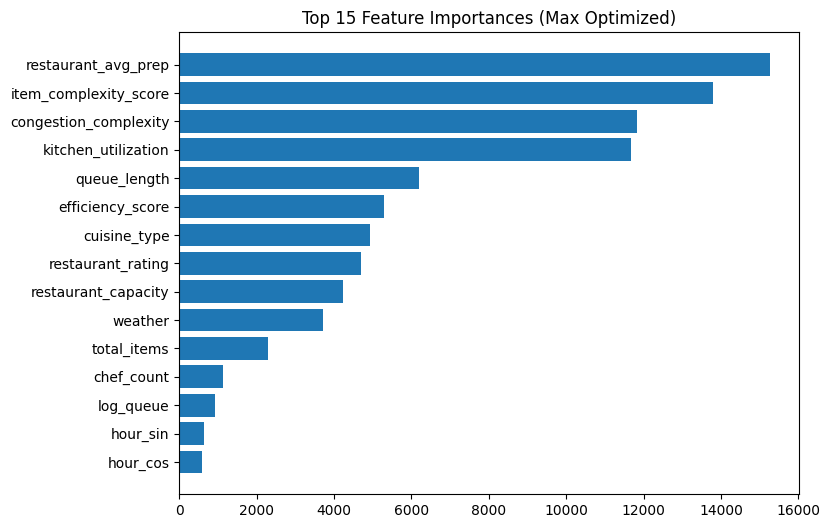


Final optimized model saved successfully.


In [ ]:
# This pipeline trains a congestion-aware KPT prediction model using robust loss, time-series validation, and weighted learning.
# Designed for realistic deployment in delivery operations.

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import joblib

# LOAD FEATURE-ENGINEERED DATA
# This dataset already contains:
# - Operational features
# - Congestion signals
# - Order-level complexity
# - Environmental factors

df = pd.read_csv("zomato_kpt_feature_engineered.csv")

# ADD CONGESTION REGIME FEATURE
# Converts continuous kitchen utilization into discrete
# operational stress regimes.
#
# Why?
# Tree-based models capture categorical splits effectively.
# Regimes help model nonlinear congestion transitions.

df["congestion_regime"] = pd.cut(
    df["kitchen_utilization"],
    bins=[0, 0.6, 0.85, 1.1, 5],
    labels=[0, 1, 2, 3]
).astype(float).fillna(-1).astype(int)

# SPLIT FEATURES AND TARGET
# X → All predictive signals
# y → Actual prep_time

X = df.drop(columns=["prep_time"])
y = df["prep_time"]

print("Dataset shape:", df.shape)

# TIME SERIES CROSS VALIDATION
#
# Why TimeSeriesSplit?
# In delivery operations, future data must not leak into past.
# This simulates real deployment conditions.

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []

print("\nRunning TimeSeries Cross Validation...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Smooth congestion weighting
    #
    # Why?
    # Errors during high utilization are more costly
    # operationally (rider idle, SLA violations).
    # We weight congested samples higher.

    weights = 1 + (X_train["kitchen_utilization"] ** 2) * 2

    # MODEL CONFIGURATION
    #
    # LightGBM chosen because:
    # - Handles nonlinear congestion effects
    # - Efficient at scale
    # - Robust to mixed feature types
    #
    # Huber loss used to:
    # - Reduce sensitivity to extreme outliers
    # - Handle heavy-tail rare delay events

    model = lgb.LGBMRegressor(
        objective="huber",
        alpha=0.9,
        n_estimators=1400,
        learning_rate=0.035,
        num_leaves=64,
        max_depth=10,
        min_child_samples=35,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.15,
        reg_lambda=0.35,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=weights,
        eval_set=[(X_val, y_val)],
        eval_metric="l1",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    mae_scores.append(mae)

    print(f"Fold {fold+1} MAE: {round(mae, 3)}")

print("\nAverage CV MAE:", round(np.mean(mae_scores), 3))

# FINAL TRAIN-TEST SPLIT (80-20 SEQUENTIAL SPLIT)
#
# Keeps last 20% as future test window.
# Simulates real-world production rollout.

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Higher weight for congested states in final training
final_weights = 1 + (X_train["kitchen_utilization"] ** 2) * 2

# FINAL MODEL TRAINING
# Same hyperparameters validated via cross-validation.

final_model = lgb.LGBMRegressor(
    objective="huber",
    alpha=0.9,
    n_estimators=1400,
    learning_rate=0.035,
    num_leaves=64,
    max_depth=10,
    min_child_samples=35,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.15,
    reg_lambda=0.35,
    random_state=42
)

final_model.fit(
    X_train,
    y_train,
    sample_weight=final_weights,
    eval_set=[(X_test, y_test)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(100)]
)

# PREDICTIONS ON FUTURE DATA

y_pred = final_model.predict(X_test)

# EVALUATION METRICS
#
# MAE → Operational interpretability (minutes error)
# RMSE → Penalizes larger deviations
# R² → Overall explanatory power

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nFINAL TEST PERFORMANCE (Max Optimized)")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 4))

# PERFORMANCE UNDER CONGESTION
# Why?
# Accuracy during peak hours matters more than average accuracy.

df_test = df.iloc[split_index:].copy()
df_test["prediction"] = y_pred

congestion_condition = df_test["kitchen_utilization"] > 0.8

mae_cong = mean_absolute_error(
    df_test[congestion_condition]["prep_time"],
    df_test[congestion_condition]["prediction"]
)

mae_normal = mean_absolute_error(
    df_test[~congestion_condition]["prep_time"],
    df_test[~congestion_condition]["prediction"]
)

print("\nMAE during Congestion:", round(mae_cong, 3))
print("MAE during Normal:", round(mae_normal, 3))

# FEATURE IMPORTANCE ANALYSIS
#
# Helps interpret:
# - What drives prep time most
# - Operational leverage points

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 15 Feature Importances:\n")
print(importances.head(15))

plt.figure(figsize=(8,6))
plt.barh(importances["feature"][:15], importances["importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Max Optimized)")
plt.show()

# SAVE MODEL FOR DEPLOYMENT
#
# The trained model is serialized for:
# - Real-time inference
# - Integration into dispatch system
# - Future retraining

joblib.dump(final_model, "kpt_final_max_optimized.pkl")
print("\nFinal optimized model saved successfully.")

**Selecting this training pipeline as the best model to go forward with**

Why This Pipeline Was Selected
1. Best Congestion Performance

Significant reduction in congestion MAE (from >3.3 to ~2.7).

2. Higher R²

Explains ~87% of prep time variance.

3. Stable Cross Validation

Average CV MAE ≈ 2.02 across 5 time folds.

4. Clean Deployment Architecture

Single model
No routing logic
Easy to productionize

5. Strong Feature Interpretability

Top drivers:

Restaurant historical average prep

Item complexity

Kitchen utilization

Congestion complexity

Queue length

These align with real-world operational intuition.